# 02 · Exploratory data analysis

Univariate and bivariate exploration of the cleaned Superstore data: category/region/segment breakdowns, the discount-vs-profit relationship, correlations, seasonality via STL decomposition, and the top customers / products / loss-making sub-categories.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

from src.data_loader import load_clean
from src.plotting import set_style, savefig
from src.config import TABLE_DIR

set_style()
sns.set_palette('deep')
df = load_clean()
df['profit_margin'] = df['Profit'] / df['Sales']
df['is_loss'] = (df['Profit'] < 0).astype(int)
df.shape

(9994, 26)

## 1 · Univariate — numeric

In [2]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'profit_margin', 'Ship Days']
df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Sales,9994.0,229.858001,623.245101,0.444,2.286000,4.980000,17.28000,54.4900,209.9400,956.984245,2481.694600,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,1.000000,1.000000,2.00000,3.0000,5.0000,8.000000,11.000000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.000000,0.000000,0.00000,0.2000,0.2000,0.700000,0.800000,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,-319.264953,-53.030920,1.72875,8.6665,29.3640,168.470400,580.657882,8399.976
profit_margin,9994.0,0.120314,0.466754,-2.750,-1.750000,-0.766667,0.07500,0.2700,0.3625,0.480000,0.500000,0.500
Ship Days,9994.0,3.958175,1.747567,0.000,0.000000,0.000000,3.00000,4.0000,5.0000,7.000000,7.000000,7.000


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_univariate_numeric.png


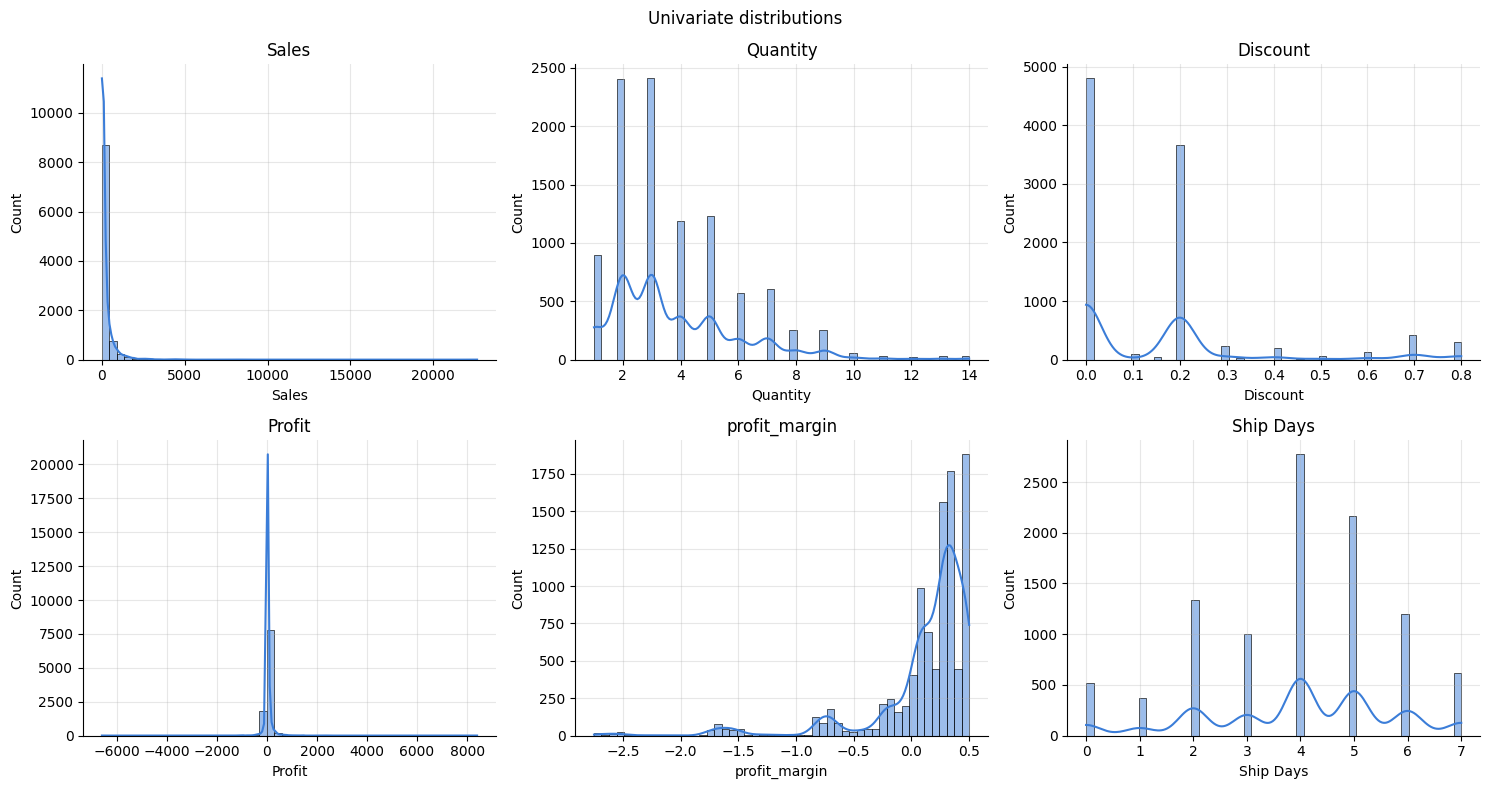

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=50, ax=ax, kde=True, color='#3b7dd8')
    ax.set_title(col)
fig.suptitle('Univariate distributions')
print(savefig(fig, '02_univariate_numeric'))
plt.show()

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_log_transforms.png


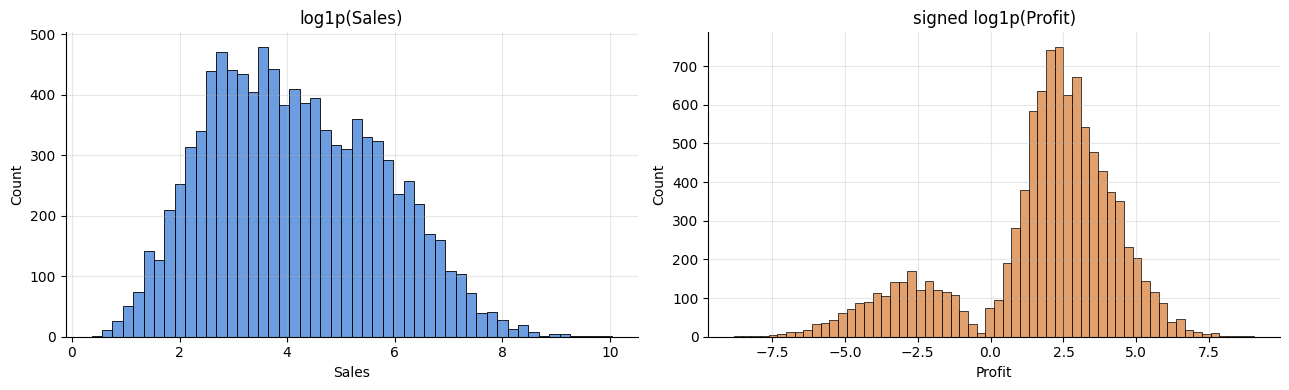

In [4]:
# log1p on the signed-heavy columns to see structure
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(np.log1p(df['Sales']), bins=50, ax=axes[0], color='#3b7dd8')
axes[0].set_title('log1p(Sales)')
sns.histplot(np.sign(df['Profit']) * np.log1p(df['Profit'].abs()), bins=60, ax=axes[1], color='#d8813b')
axes[1].set_title('signed log1p(Profit)')
print(savefig(fig, '02_log_transforms'))
plt.show()

## 2 · Univariate — categorical

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_univariate_categorical.png


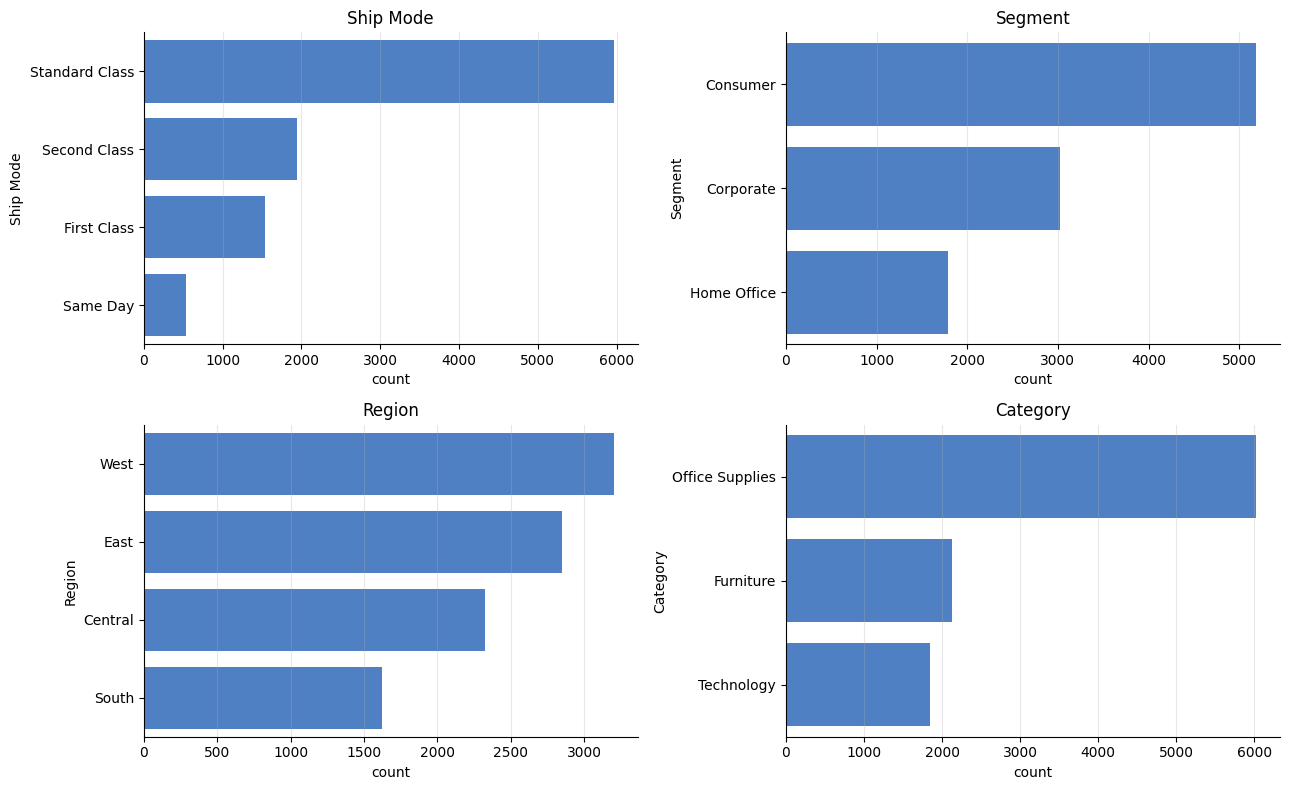

In [5]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color='#3b7dd8')
    ax.set_title(col)
print(savefig(fig, '02_univariate_categorical'))
plt.show()

## 3 · Sales & profit by category / sub-category

In [6]:
by_cat = (df.groupby(['Category', 'Sub-Category'])
            .agg(sales=('Sales', 'sum'), profit=('Profit', 'sum'),
                 orders=('Order ID', 'nunique'), lines=('Row ID', 'size'),
                 avg_discount=('Discount', 'mean'))
            .reset_index())
by_cat['margin'] = by_cat['profit'] / by_cat['sales']
by_cat = by_cat.sort_values('profit')
by_cat.to_csv(TABLE_DIR / '02_by_subcategory.csv', index=False)
by_cat

,Category,Sub-Category,sales,profit,orders,lines,avg_discount,margin
3,Furniture,Tables,206965.5320,-17725.4811,307,319,0.261285,-0.085645
0,Furniture,Bookcases,114879.9963,-3472.5560,224,228,0.211140,-0.030228
12,Office Supplies,Supplies,46673.5380,-1189.0995,187,190,0.076842,-0.025477
8,Office Supplies,Fasteners,3024.2800,949.5182,215,217,0.082028,0.313965
15,Technology,Machines,189238.6310,3384.7569,112,115,0.306087,0.017886
9,Office Supplies,Labels,12486.3120,5546.2540,346,364,0.068681,0.444187
5,Office Supplies,Art,27118.7920,6527.7870,731,796,0.074874,0.240711
7,Office Supplies,Envelopes,16476.4020,6964.1767,249,254,0.080315,0.422676
2,Furniture,Furnishings,91705.1640,13059.1436,877,957,0.138349,0.142404
4,Office Supplies,Appliances,107532.1610,18138.0054,451,466,0.166524,0.168675


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_profit_by_subcategory.png


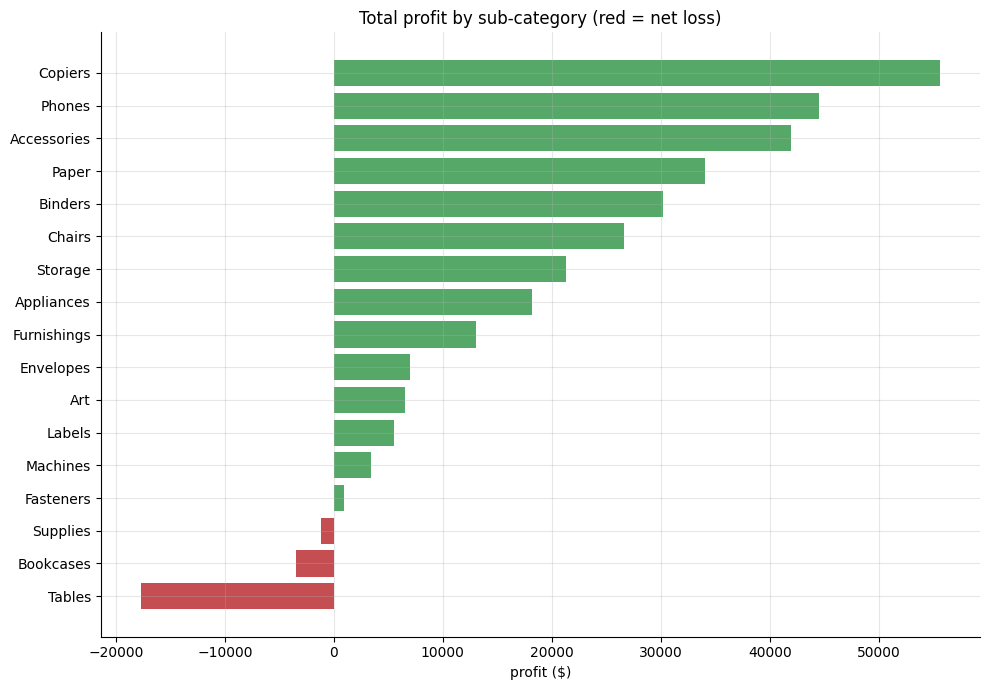

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c44e52' if p < 0 else '#55a868' for p in by_cat['profit']]
ax.barh(by_cat['Sub-Category'], by_cat['profit'], color=colors)
ax.set_title('Total profit by sub-category (red = net loss)')
ax.set_xlabel('profit ($)')
print(savefig(fig, '02_profit_by_subcategory'))
plt.show()

## 4 · Region & segment

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_region_segment_heatmap.png


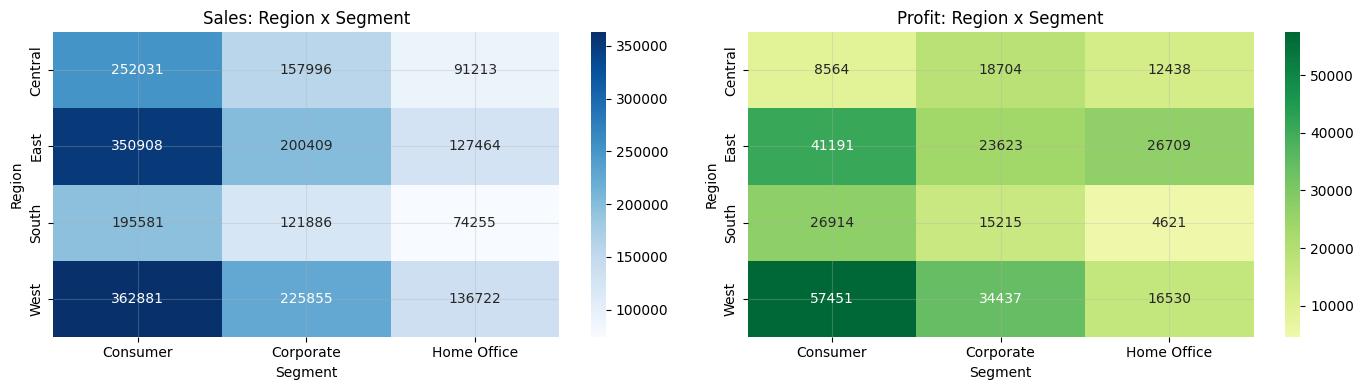

In [8]:
pivot_sales = df.pivot_table('Sales', 'Region', 'Segment', aggfunc='sum')
pivot_profit = df.pivot_table('Profit', 'Region', 'Segment', aggfunc='sum')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Sales: Region x Segment')
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('Profit: Region x Segment')
print(savefig(fig, '02_region_segment_heatmap'))
plt.show()

## 5 · Discount vs profit

The single most important operational relationship in this dataset.

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_discount_vs_profit.png


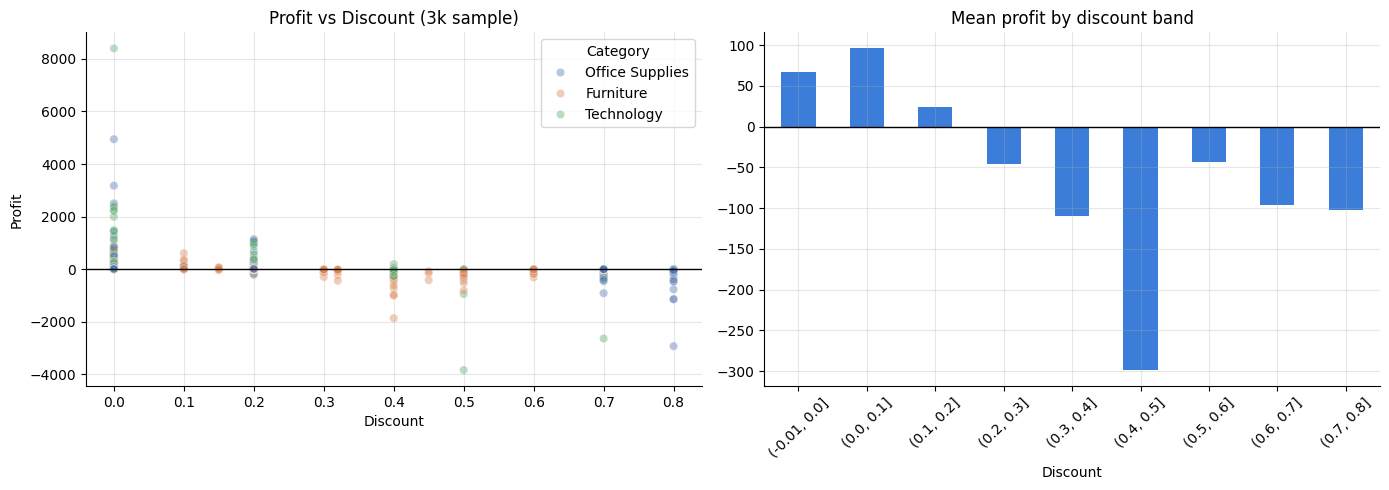

,avg_profit,loss_rate,n
Discount,,,
"(-0.01, 0.0]",66.900292,0.000000,4798
"(0.0, 0.1]",96.055074,0.042553,94
"(0.1, 0.2]",24.738824,0.139930,3709
"(0.2, 0.3]",-45.679636,0.916300,227
"(0.3, 0.4]",-109.219691,0.888412,233
"(0.4, 0.5]",-298.695314,1.000000,77
"(0.5, 0.6]",-43.077212,1.000000,138
"(0.6, 0.7]",-95.874060,1.000000,418
"(0.7, 0.8]",-101.796797,1.000000,300


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(3000, random_state=0), x='Discount', y='Profit',
                hue='Category', alpha=0.4, ax=axes[0])
axes[0].axhline(0, color='k', lw=1)
axes[0].set_title('Profit vs Discount (3k sample)')

disc_bin = pd.cut(df['Discount'], bins=[-.01, 0, .1, .2, .3, .4, .5, .6, .7, .8, 1])
g = df.groupby(disc_bin, observed=True).agg(avg_profit=('Profit', 'mean'),
                                            loss_rate=('is_loss', 'mean'),
                                            n=('Row ID', 'size'))
g['avg_profit'].plot(kind='bar', ax=axes[1], color='#3b7dd8')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_title('Mean profit by discount band')
axes[1].tick_params(axis='x', rotation=45)
print(savefig(fig, '02_discount_vs_profit'))
plt.show()
g

In [10]:
print('Loss-making lines overall: {:.1%}'.format(df['is_loss'].mean()))
print('Loss rate at discount == 0 : {:.1%}'.format(df.loc[df.Discount == 0, 'is_loss'].mean()))
print('Loss rate at discount >= 0.3: {:.1%}'.format(df.loc[df.Discount >= 0.3, 'is_loss'].mean()))

Loss-making lines overall: 18.7%
Loss rate at discount == 0 : 0.0%
Loss rate at discount >= 0.3: 96.8%


## 6 · Correlation (numeric)

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_correlation.png


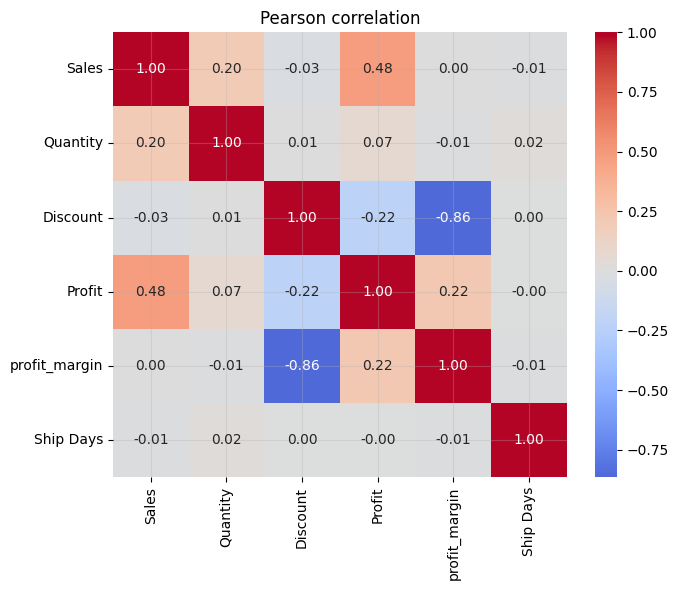

In [11]:
corr = df[['Sales', 'Quantity', 'Discount', 'Profit', 'profit_margin', 'Ship Days']].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson correlation')
print(savefig(fig, '02_correlation'))
plt.show()

## 7 · Time series & seasonality

Monthly sales, STL decomposition (period = 12), and a month-of-year profile.

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_stl_decomposition.png


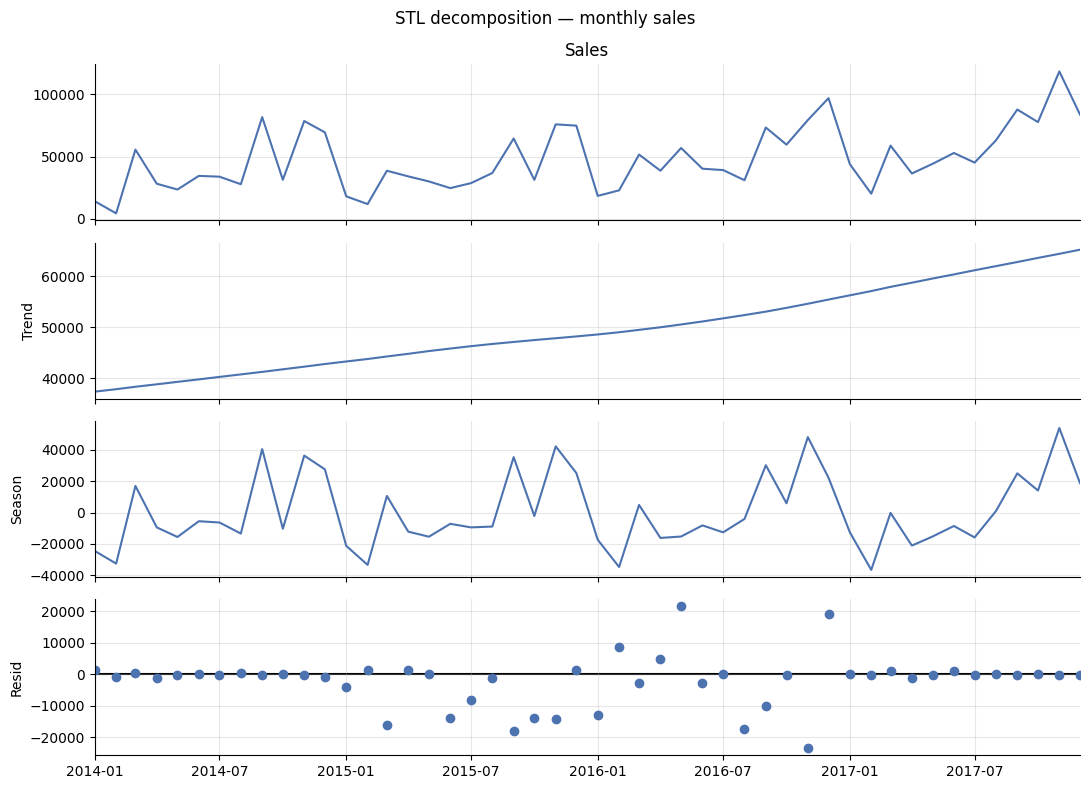

In [12]:
monthly = (df.set_index('Order Date')
             .resample('MS')['Sales'].sum())
stl = STL(monthly, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 8)
fig.suptitle('STL decomposition — monthly sales')
print(savefig(fig, '02_stl_decomposition'))
plt.show()

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\02_seasonal_profiles.png


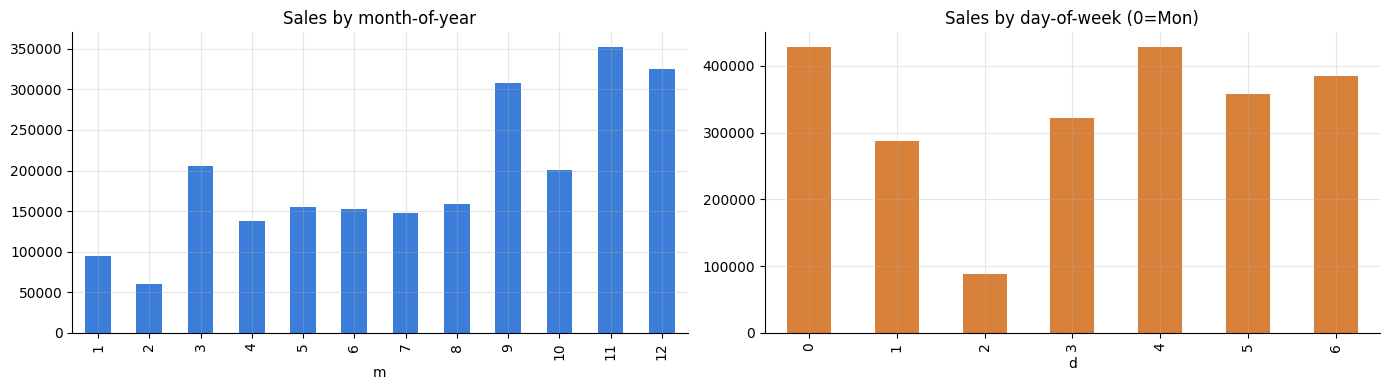

In [13]:
moy = df.assign(m=df['Order Date'].dt.month).groupby('m')['Sales'].sum()
dow = df.assign(d=df['Order Date'].dt.dayofweek).groupby('d')['Sales'].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
moy.plot(kind='bar', ax=axes[0], color='#3b7dd8'); axes[0].set_title('Sales by month-of-year')
dow.plot(kind='bar', ax=axes[1], color='#d8813b'); axes[1].set_title('Sales by day-of-week (0=Mon)')
print(savefig(fig, '02_seasonal_profiles'))
plt.show()

## 8 · Top / bottom performers

In [14]:
top_cust = (df.groupby('Customer Name')
              .agg(sales=('Sales', 'sum'), profit=('Profit', 'sum'), orders=('Order ID', 'nunique'))
              .sort_values('sales', ascending=False).head(10))
top_prod = (df.groupby('Product Name')
              .agg(sales=('Sales', 'sum'), profit=('Profit', 'sum'), qty=('Quantity', 'sum'))
              .sort_values('sales', ascending=False).head(10))
worst_prod = (df.groupby('Product Name')['Profit'].sum().sort_values().head(10))
top_cust.to_csv(TABLE_DIR / '02_top_customers.csv')
top_prod.to_csv(TABLE_DIR / '02_top_products.csv')
display(top_cust)
display(top_prod)
display(worst_prod.to_frame('profit'))

,sales,profit,orders
Customer Name,,,
Sean Miller,25043.050,-1980.7393,5
Tamara Chand,19052.218,8981.3239,5
Raymond Buch,15117.339,6976.0959,6
Tom Ashbrook,14595.620,4703.7883,4
Adrian Barton,14473.571,5444.8055,10
Ken Lonsdale,14175.229,806.8550,12
Sanjit Chand,14142.334,5757.4119,9
Hunter Lopez,12873.298,5622.4292,6
Sanjit Engle,12209.438,2650.6769,11


,sales,profit,qty
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


,profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


## 9 · Order-level view

Most modelling later is at the line level, but discounting and basket size act at the order level.

In [15]:
orders = (df.groupby('Order ID')
            .agg(order_date=('Order Date', 'first'), region=('Region', 'first'),
                 segment=('Segment', 'first'), sales=('Sales', 'sum'),
                 profit=('Profit', 'sum'), lines=('Row ID', 'size'),
                 qty=('Quantity', 'sum'), avg_discount=('Discount', 'mean')))
print('orders:', len(orders))
orders.describe().T

orders: 5009


,count,mean,min,25%,50%,75%,max,std
order_date,5009,2016-05-07 16:04:47.482531328,2014-01-03 00:00:00,2015-05-31 00:00:00,2016-07-10 00:00:00,2017-05-19 00:00:00,2017-12-30 00:00:00,NaN
sales,5009.0,458.614666,0.556,37.63,151.96,512.064,23661.228,954.730953
profit,5009.0,57.176487,-6892.3748,2.0525,16.2758,68.6868,8762.3891,344.937752
lines,5009.0,1.995209,1.0,1.0,1.0,2.0,14.0,1.410671
qty,5009.0,7.56099,1.0,3.0,6.0,10.0,52.0,6.220034
avg_discount,5009.0,0.156812,0.0,0.0,0.1,0.2,0.8,0.190829


## Takeaways

- **Tables** (Furniture) and **Bookcases** are net loss-makers; Binders and Machines carry large losses at high discount despite strong sales.
- Profit collapses once **Discount ≥ 0.3**: mean profit goes negative and the loss rate jumps from ~3% (no discount) to well over 50%.
- `Sales`↔`Profit` correlate ~0.48; `Discount`↔`Profit` is clearly negative. `Quantity` barely moves profit.
- Strong upward trend + December peak in the STL seasonal component → use a seasonal model in `04_forecasting.ipynb`.
- Central region / Consumer-Furniture is the weakest cell on profit.

Next: `03_feature_engineering.ipynb`.